# Regression Modeling without Lag Features

## Data Split

In [1]:
import pandas as pd
# Load dataset
df = pd.read_csv('../data/interim/preprocessed_df2.csv')

In [2]:
from sklearn.model_selection import train_test_split

# Drop rows with missing values
df_cleaned = df.dropna()

# Verify if there are any missing values left
print("Number of missing values:", df_cleaned.isnull().sum().sum())

# Define features and target
features = [
    'PM10 1H (µg/m3)', 'PM2.5 1H (µg/m3)', 'SO2 1H (ppm)', 'NO2 1H (ppm)',
    'O3 1H (ppm)', 'CO 1H (ppm)', 'WIND DIRECTION 1H (°)',
    'WIND SPEED 1H (m/s)', 'RELATIVE HUMIDITY 1H (%)', 'Ambient Temperature 1H (°c)'
]
X = df_cleaned[features]  # Feature matrix
y = df_cleaned['API']     # Target variable

# Train-Test Split
seed_value = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed_value)

# Confirm shapes of the datasets
print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

Number of missing values: 0
Training set: (196352, 10) (196352,)
Test set: (49088, 10) (49088,)


## Set Up

In [3]:
import os
import pickle
import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set random seed
seed_value = 42

# Define save location
model_folder_path = "../models/regression/no_lag_values"
if not os.path.exists(model_folder_path):
    os.makedirs(model_folder_path)

report_folder_path = "../reports/regression/no_lag_values"
if not os.path.exists(report_folder_path):
    os.makedirs(report_folder_path)

In [4]:
# Define evaluation metrics
def evaluate_regression_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    return mae, mse, rmse, r2

In [5]:
# Define GridSearchCV function
def grid_search_tuning(model, param_grid, X_train, y_train):
    grid_search = GridSearchCV(estimator=model, 
                               param_grid=param_grid, 
                               cv=5, scoring='neg_mean_squared_error', 
                               n_jobs=-1, error_score='raise')
    grid_search.fit(X_train, y_train)
    return grid_search.best_estimator_


In [6]:
# Define parameter grids
param_grid_lasso = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]}

param_grid_dt = {
    'max_depth': [3, 5, 10, 20, 30, None],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 5, 10, 20],
    'max_features': [None, 'sqrt', 'log2']
}

param_grid_rf = {
    'n_estimators': [100, 300],
    'max_depth': [None, 20],
    'min_samples_split': [2, 10],
}

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 10],
}

In [7]:
# Define models
regression_lasso = Lasso()
regression_dt = DecisionTreeRegressor(random_state=seed_value)
regression_rf = RandomForestRegressor(random_state=seed_value)
regression_xgb = XGBRegressor(random_state=seed_value, objective='reg:squarederror')


In [8]:
# Save model function
def save_model(model, file_path: str):
    with open(file_path, 'wb') as f:
        pickle.dump(model, f)
    print(f"Model saved to {file_path}")

## Model Training

In [9]:
# Training and saving
print('Training Regression Models...')

Training Regression Models...


In [10]:
print('LASSO model...')
regression_lasso_model = grid_search_tuning(regression_lasso, param_grid_lasso, X_train, y_train)
save_model(regression_lasso_model, f'{model_folder_path}/regression_lasso_model.pkl')


LASSO model...


Model saved to ../models/regression/no_lag_values/regression_lasso_model.pkl


In [11]:
print('Decision Tree model...')
regression_dt_model = grid_search_tuning(regression_dt, param_grid_dt, X_train, y_train)
save_model(regression_dt_model, f'{model_folder_path}/regression_dt_model.pkl')

Decision Tree model...
Model saved to ../models/regression/no_lag_values/regression_dt_model.pkl


In [12]:
print('Random Forest model...')
regression_rf_model = grid_search_tuning(regression_rf, param_grid_rf, X_train, y_train)
save_model(regression_rf_model, f'{model_folder_path}/regression_rf_model.pkl')

Random Forest model...
Model saved to ../models/regression/no_lag_values/regression_rf_model.pkl


In [13]:
print('XGBoost model...')
regression_xgb_model = grid_search_tuning(regression_xgb, param_grid_xgb, X_train, y_train)
save_model(regression_xgb_model, f'{model_folder_path}/regression_xgb_model.pkl')

XGBoost model...
Model saved to ../models/regression/no_lag_values/regression_xgb_model.pkl


## Model Evaluation

In [ ]:
# Evaluate all models
regression_models = {
    'LASSO': regression_lasso_model,
    'Decision Tree': regression_dt_model,
    'Random Forest': regression_rf_model,
    'XGBoost': regression_xgb_model
}

regression_results = {}
for name, model in regression_models.items():
    regression_results[name] = evaluate_regression_model(model, X_test, y_test)

# Results to DataFrame
regression_results_df = pd.DataFrame.from_dict(regression_results, orient='index', 
                                               columns=['MAE', 'MSE', 'RMSE', 'R2'])

regression_results_df.to_csv(f'{report_folder_path}/regression_test_performance.csv')
regression_results_df

,MAE,MSE,RMSE,R2
LASSO,7.625349,123.677192,11.121025,0.227464
Decision Tree,7.587115,119.312500,10.923026,0.254728
Random Forest,7.120100,105.011611,10.247517,0.344057
XGBoost,7.108119,103.153870,10.156469,0.355661


The test evaluation results show that XGBoost is the best model, given its highest R2 value and lowest RMSE value.

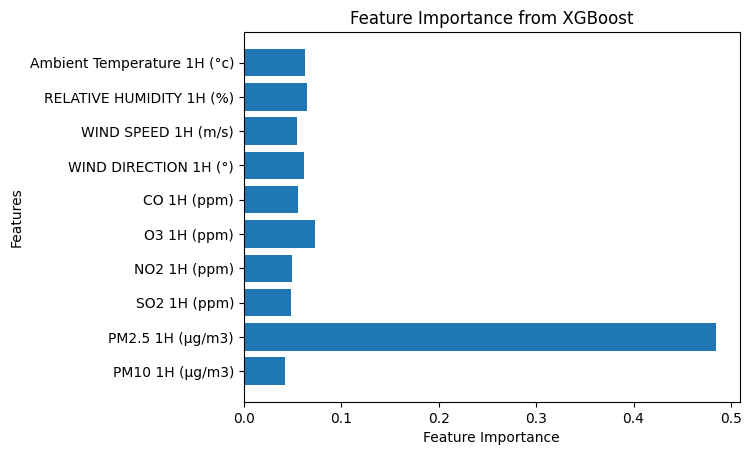

In [6]:
import matplotlib.pyplot as plt

# Plot feature importance
xgb_importance = regression_xgb_model.feature_importances_
plt.barh(X_train.columns, xgb_importance)
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance from XGBoost')
plt.show()

PM2.5 has the highest feature importance. 

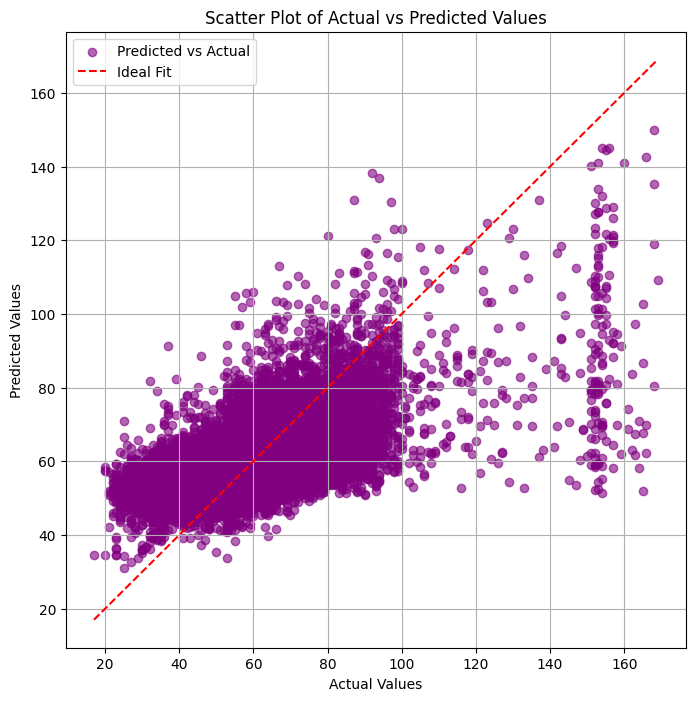

In [4]:
import matplotlib.pyplot as plt

regression_xgb_model = joblib.load('../models/regression/no_lag_values/regression_xgb_model.pkl')
# Scatter plot for Actual vs Predicted values
y_pred_best_model = regression_xgb_model.predict(X_test)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_best_model, color='purple', alpha=0.6, label="Predicted vs Actual")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label="Ideal Fit")
plt.title("Scatter Plot of Actual vs Predicted Values")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.grid(True)
plt.show()
